# Cross-Domain Generalisation – Distortion & Performance Analysis

This notebook implements the analysis pipeline for the cross-domain generalisation experiment.  
It assumes that the following CSV files have already been generated:

- `distortions_all_datasets.csv` – **per-image** visual distortion metrics (turbidity, blur, RGB ratios, UIQM, UCIQE, etc.)
- `dataset_distortion_summary_full.csv` – **per-dataset** summary statistics (means / stds of all distortion metrics)

The goals of this notebook are:

1. Load and inspect the distortion metrics for all datasets.
2. Compare datasets in terms of turbidity, contrast, blur, colour cast, UIQM and UCIQE.
3. Select unseen test domains for the cross-domain experiment based on these distortions.
4. (Later) Merge per-image distortion metrics with per-image detection performance to analyse which distortions cause performance collapse.

> **Note:** Model training and per-image evaluation are run separately (with YOLO).  
> This notebook focuses on the **analysis** once the CSVs are available.

## 1. Imports and configuration

Edit the paths below if your CSV files live in a different directory.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:0.6f}')

ROOT = Path('Data1/mpiccolo/HT_Vision/Controlled_cross_domain_generalization')

CSV_DISTORTIONS = ROOT / 'distortions_all_datasets.csv'
CSV_DATASET_SUMMARY = ROOT / 'dataset_distortion_summary_full.csv'

CSV_DISTORTIONS, CSV_DATASET_SUMMARY

(PosixPath('/mnt/Data1/mpiccolo/HT_Vision/Controlled_cross_domain_generalization/distortions_all_datasets.csv'),
 PosixPath('/mnt/Data1/mpiccolo/HT_Vision/Controlled_cross_domain_generalization/dataset_distortion_summary_full.csv'))

## 2. Load distortion metrics

We load:

- `distortions_all_datasets.csv`: one row per image with raw distortion metrics.
- `dataset_distortion_summary_full.csv`: one row per dataset with aggregated metrics.

Then we do a quick sanity check on shapes and a preview of the tables.

In [2]:
distortions = pd.read_csv(CSV_DISTORTIONS)
dataset_summary = pd.read_csv(CSV_DATASET_SUMMARY)

print('Per-image distortions shape:', distortions.shape)
print('Per-dataset summary shape:', dataset_summary.shape)

distortions.head()

Per-image distortions shape: (28765, 15)
Per-dataset summary shape: (10, 24)


,dataset,path_rel,turbidity,blue_ratio,green_ratio,red_ratio,contrast,blur_var_laplacian,uiqm,uicm,uism,uiconm,uciqe,fish_count,mean_iou_overlap
0,AquaCoop,AquaCoop/images/AquaCoop_01217.jpg,0.115074,0.332942,0.384627,0.282431,0.066663,2.646765,0.622253,1.264695,0.016715,0.162687,4.712023,23,0.119487
1,AquaCoop,AquaCoop/images/AquaCoop_00109.jpg,0.052302,0.417080,0.323054,0.259867,0.031167,1.020925,0.372260,1.560304,0.008840,0.091083,11.818447,4,0.017392
2,AquaCoop,AquaCoop/images/AquaCoop_01203.jpg,0.130606,0.376721,0.326785,0.296494,0.054079,3.182700,0.597883,2.309086,0.019189,0.147428,5.063146,13,0.109645
3,AquaCoop,AquaCoop/images/AquaCoop_00135.jpg,0.027801,0.414098,0.311070,0.274832,0.021176,1.379734,0.257200,0.832843,0.009740,0.064565,138.845001,3,0.000000
4,AquaCoop,AquaCoop/images/AquaCoop_00653.jpg,0.051603,0.336251,0.382439,0.281310,0.047197,1.901370,0.457774,1.453581,0.013370,0.115469,14.477638,12,0.087872


In [3]:
dataset_summary.head()

,dataset,turbidity,turbidity.1,contrast,contrast.1,blur_var_laplacian,blur_var_laplacian.1,blue_ratio,green_ratio,red_ratio,...,uicm,uicm.1,uism,uism.1,uiconm,uiconm.1,fish_count,fish_count.1,mean_iou_overlap,mean_iou_overlap.1
0,NaN,mean,std,mean,std,mean,std,mean,mean,mean,...,mean,std,mean,std,mean,std,mean,std,mean,std
1,AquaCoop,0.13818222017182402,0.10041052580283824,0.05526598993318695,0.020098977810844652,4.935778471714687,5.05351929619846,0.3693946929037667,0.33759347331350564,0.29301182581457835,...,1.8695375751072063,0.9390462501935376,0.021794430029210592,0.01047144963362492,0.14638385741771323,0.04836682844218833,11.060581583198708,5.3330816047382195,0.07369803294715482,0.052914233957655814
2,OzFish,0.05292683764600931,0.07841003437609072,0.10045048152761796,0.03597625165632724,249.04116232776062,273.2173384855177,0.4739647023166929,0.45636810490063257,0.06966719220192832,...,13.755889688219343,3.065266087914067,0.11501950618411809,0.06679463999461695,0.25050812746797285,0.047952111791278736,21.542857142857144,17.097634443430913,0.07613155012850513,0.05653730632875711
3,aquarium,0.18026387355862555,0.09539490321373088,0.178777998094001,0.04625458012399357,217.84377415885007,325.6338496006228,0.415615290824435,0.3234828851497154,0.2609018231486226,...,7.718418830792234,4.140612193587216,0.13707971651607087,0.07046452622951177,0.3192773519472761,0.06203091006930837,7.56828885400314,8.395143047283751,0.047846868834387,0.07171552019873774
4,deepfish,0.29837058998306343,0.12044275197917334,0.09817791901917486,0.03635552452834107,53.56483672251926,44.772867785316095,0.3780130326747894,0.3817337546245372,0.24025321186672102,...,8.809518334286063,4.489048616600972,0.07328088127167584,0.023899880004745404,0.25739559136273193,0.0461965775542371,3.432408435072142,3.1441700952760674,0.018454990843832054,0.04874506149611537


## 3. Tidy per-dataset summary

The summary CSV may contain an extra header row with the strings `mean` and `std`.
We flatten this into simple column names such as `turbidity_mean`, `turbidity_std`, etc., and
keep only the meaningful rows (one per dataset).

In [4]:
summary = dataset_summary.copy()

first_row = summary.iloc[0].astype(str).tolist()
if any('mean' in v.lower() or 'std' in v.lower() for v in first_row):
    cols = list(summary.columns)
    level1 = [str(c) for c in cols]
    level2 = [str(v) for v in first_row]

    new_cols = []
    for c1, c2 in zip(level1, level2):
        c1_clean = c1.strip()
        c2_clean = c2.strip()
        if c1_clean == 'dataset':
            new_cols.append('dataset')
        elif c2_clean in ('mean', 'std'):
            new_cols.append(f"{c1_clean}_{c2_clean}")
        else:
            new_cols.append(c1_clean)

    summary.columns = new_cols
    summary = summary.iloc[1:].reset_index(drop=True)

print('Shape is: ',summary.shape)
summary


Shape is:  (9, 24)


,dataset,turbidity_mean,turbidity.1_std,contrast_mean,contrast.1_std,blur_var_laplacian_mean,blur_var_laplacian.1_std,blue_ratio_mean,green_ratio_mean,red_ratio_mean,...,uicm_mean,uicm.1_std,uism_mean,uism.1_std,uiconm_mean,uiconm.1_std,fish_count_mean,fish_count.1_std,mean_iou_overlap_mean,mean_iou_overlap.1_std
0,AquaCoop,0.13818222017182402,0.10041052580283824,0.05526598993318695,0.020098977810844652,4.935778471714687,5.05351929619846,0.3693946929037667,0.33759347331350564,0.29301182581457835,...,1.8695375751072063,0.9390462501935376,0.021794430029210592,0.01047144963362492,0.14638385741771323,0.04836682844218833,11.060581583198708,5.3330816047382195,0.07369803294715482,0.052914233957655814
1,OzFish,0.05292683764600931,0.07841003437609072,0.10045048152761796,0.03597625165632724,249.04116232776062,273.2173384855177,0.4739647023166929,0.45636810490063257,0.06966719220192832,...,13.755889688219343,3.065266087914067,0.11501950618411809,0.06679463999461695,0.25050812746797285,0.047952111791278736,21.542857142857144,17.097634443430913,0.07613155012850513,0.05653730632875711
2,aquarium,0.18026387355862555,0.09539490321373088,0.178777998094001,0.04625458012399357,217.84377415885007,325.6338496006228,0.415615290824435,0.3234828851497154,0.2609018231486226,...,7.718418830792234,4.140612193587216,0.13707971651607087,0.07046452622951177,0.3192773519472761,0.06203091006930837,7.56828885400314,8.395143047283751,0.047846868834387,0.07171552019873774
3,deepfish,0.29837058998306343,0.12044275197917334,0.09817791901917486,0.03635552452834107,53.56483672251926,44.772867785316095,0.3780130326747894,0.3817337546245372,0.24025321186672102,...,8.809518334286063,4.489048616600972,0.07328088127167584,0.023899880004745404,0.25739559136273193,0.0461965775542371,3.432408435072142,3.1441700952760674,0.018454990843832054,0.04874506149611537
4,deepfish_negatives,0.31056607560792504,0.12064904960557427,0.08684645486332723,0.03081155880685035,49.118174312329934,38.65872962548021,0.3840595733663197,0.37517117388976023,0.2407692536326573,...,8.277495513201709,4.45976468841156,0.06860504156648813,0.019054757713252265,0.24290404541355,0.0411539895857099,0.0,0.0,0.0,0.0
5,f4k,0.22778307651204782,0.0948660275366138,0.28090494683467465,0.03961533049535551,2050.2058720434397,1027.551390270327,0.3310015650855504,0.34522670518691356,0.3237717307972668,...,9.929343126282584,4.221033492384455,0.387794722307952,0.14453172717818305,0.446763022758198,0.03411627511508539,3.8463476070528966,3.5385205777297597,0.008571305031238824,0.023975987107562973
6,fish_416,0.14647810962674152,0.09854769691490312,0.15388478329679103,0.0565113949059148,273.28372871076476,420.2478309621885,0.4198013506610604,0.35625092374051315,0.2239477278616772,...,8.446263057168792,4.057918147492915,0.16326760999611847,0.10630536167800582,0.29798001061905827,0.06599595529307385,2.3264705882352943,3.4839255383429713,0.019347504395580677,0.050056086744921034
7,fishclef,0.19666468843338508,0.06981825679501241,0.2792799589727568,0.04167161158540479,1811.8514556664002,1052.9602927030758,0.33208028689326463,0.3449906534172429,0.32292905966026014,...,9.857089503731999,3.8944162734744556,0.3729201118192759,0.13573577894003433,0.43685540479024476,0.029715129180283937,1.5853009178168571,0.8550494690307504,0.0033486090712189333,0.029069985128847897
8,luderick,0.13586139477585973,0.09794830301206296,0.13674697145415418,0.03757915416187526,522.2151227725969,103.73375895954952,0.40252126421225304,0.45464516937091487,0.14283356414863901,...,16.541974120992048,5.278858744674972,0.10753714666467494,0.03722912183901876,0.3051495839143825,0.04521429805278339,2.2050982226379796,2.367574763203037,0.009815374678058292,0.030335487811693162


## 3.5 Density and occlusion metrics

In addition to visual distortions, this analysis also considers how many fish are present in each image and how often they overlap. These aspects are summarised by two additional metrics already stored in the CSV files: `fish_count`, which counts the number of annotated fish per image, and `mean_iou_overlap`, which provides a coarse occlusion score based on the average overlap between bounding boxes. Including these measures allows the cross-domain selection and correlation analysis to account for both image quality and scene complexity.

## 4. Compare datasets by distortion metrics

We build a compact table with the most relevant metrics per dataset:

- `turbidity_mean`
- `contrast_mean`
- `blur_var_laplacian_mean`
- `blue_ratio_mean`, `green_ratio_mean`, `red_ratio_mean`
- `uiqm_mean`, `uciqe_mean`

This helps us understand which domains are visually more challenging.

In [ ]:
cols_keep = [c for c in summary.columns if any(key in c for key in [
    'dataset',
    'turbidity_mean', 'contrast_mean', 'blur_var_laplacian_mean',
    'blue_ratio_mean', 'green_ratio_mean', 'red_ratio_mean',
    'uiqm_mean', 'uciqe_mean',
    'fish_count_mean', 'mean_iou_overlap_mean'
])]

summary_small = summary[cols_keep].copy()
summary_small = summary_small.round(5)

summary_norm = summary_small.copy()

higher_worse = ['turbidity_mean', 'fish_count_mean', 'mean_iou_overlap_mean']
lower_worse  = ['contrast_mean', 'blur_var_laplacian_mean',
                'uiqm_mean', 'uciqe_mean']
cast_cols    = ['blue_ratio_mean', 'green_ratio_mean', 'red_ratio_mean']

for col in summary_norm.columns:
    if col == 'dataset':
        continue

    if col in higher_worse:
        vals = summary_norm[col].astype(float)
        vmin, vmax = vals.min(), vals.max()
        if vmax > vmin:
            summary_norm[col] = (vals - vmin) / (vmax - vmin)
        else:
            summary_norm[col] = 0.0

    elif col in lower_worse:
        vals = summary_norm[col].astype(float)
        vmin, vmax = vals.min(), vals.max()
        if vmax > vmin:
            summary_norm[col] = (vmax - vals) / (vmax - vmin)
        else:
            summary_norm[col] = 0.0

    elif col in cast_cols:
        vals = summary_small[col].astype(float)
        diff = (vals - (1.0 / 3.0)).abs()
        dmin, dmax = diff.min(), diff.max()
        if dmax > dmin:
            summary_norm[col] = (diff - dmin) / (dmax - dmin)
        else:
            summary_norm[col] = 0.0

# Compute difficulty_index as mean of all normalized coloumns excludind column 'dataset'.
metric_cols = [c for c in summary_norm.columns if c != 'dataset']
summary_norm['difficulty_index'] = summary_norm[metric_cols].mean(axis=1)
print("Raw dataset distortion summary:")
display(summary_small)

print("Normalized dataset distortion summary (0=best, 1=worst):")
pd.options.display.float_format = "{:.2f}".format

summary_sorted = summary_norm.sort_values('difficulty_index', ascending=False)

display(summary_sorted)

save_path = "Data1/mpiccolo/HT_Vision/Controlled_cross_domain_generalization/normalized_dataset_distortion_summary.csv"

summary_sorted.to_csv(save_path, index=False)

print(f"\nSaved normalized summary to:\n{save_path}")


Raw dataset distortion summary:


,dataset,turbidity_mean,contrast_mean,blur_var_laplacian_mean,blue_ratio_mean,green_ratio_mean,red_ratio_mean,uiqm_mean,uciqe_mean,fish_count_mean,mean_iou_overlap_mean
0,AquaCoop,0.14,0.05526598993318695,4.94,0.3693946929037667,0.33759347331350564,0.29301182581457835,0.58,349202.10,11.06,0.07
1,OzFish,0.05,0.10045048152761796,249.04,0.4739647023166929,0.45636810490063257,0.06966719220192832,1.32,4.36,21.54,0.08
2,aquarium,0.18,0.178777998094001,217.84,0.415615290824435,0.3234828851497154,0.2609018231486226,1.40,3107.50,7.57,0.05
3,deepfish,0.30,0.09817791901917486,53.56,0.3780130326747894,0.3817337546245372,0.24025321186672102,1.19,4.44,3.43,0.02
4,deepfish_negatives,0.31,0.08684645486332723,49.12,0.3840595733663197,0.37517117388976023,0.2407692536326573,1.12,4.19,0.00,0.00
5,f4k,0.23,0.28090494683467465,2050.21,0.3310015650855504,0.34522670518691356,0.3237717307972668,1.99,59408.38,3.85,0.01
6,fish_416,0.15,0.15388478329679103,273.28,0.4198013506610604,0.35625092374051315,0.2239477278616772,1.35,113231.44,2.33,0.02
7,fishclef,0.20,0.2792799589727568,1811.85,0.33208028689326463,0.3449906534172429,0.32292905966026014,1.95,193359.65,1.59,0.00
8,luderick,0.14,0.13674697145415418,522.22,0.40252126421225304,0.45464516937091487,0.14283356414863901,1.59,8.49,2.21,0.01


Normalized dataset distortion summary (0=best, 1=worst):


,dataset,turbidity_mean,contrast_mean,blur_var_laplacian_mean,blue_ratio_mean,green_ratio_mean,red_ratio_mean,uiqm_mean,uciqe_mean,fish_count_mean,mean_iou_overlap_mean,difficulty_index
1,OzFish,0.00,0.80,0.88,1.00,1.00,1.00,0.48,1.00,1.00,1.00,0.82
3,deepfish,0.95,0.81,0.98,0.31,0.37,0.33,0.57,1.00,0.16,0.24,0.57
4,deepfish_negatives,1.00,0.86,0.98,0.35,0.32,0.33,0.62,1.00,0.00,0.00,0.55
8,luderick,0.32,0.64,0.75,0.49,0.99,0.71,0.29,1.00,0.10,0.13,0.54
0,AquaCoop,0.33,1.00,1.00,0.25,0.00,0.12,1.00,0.00,0.51,0.97,0.52
2,aquarium,0.49,0.45,0.90,0.58,0.05,0.25,0.42,0.99,0.35,0.63,0.51
6,fish_416,0.36,0.56,0.87,0.61,0.16,0.39,0.45,0.68,0.11,0.25,0.44
5,f4k,0.68,0.00,0.00,0.01,0.06,0.00,0.00,0.83,0.18,0.11,0.19
7,fishclef,0.56,0.01,0.12,0.00,0.06,0.00,0.03,0.45,0.07,0.04,0.13



Saved normalized summary to:
/mnt/Data1/mpiccolo/Yolo_test/YOLO_5Models_Comparison_v2/normalized_dataset_distortion_summary.csv


In [6]:
pd.options.display.float_format = "{:.5f}".format

numeric_cols = summary_small.select_dtypes(include="number").columns
summary_small[numeric_cols] = summary_small[numeric_cols].astype(float).round(5)

print('Datasets ranked by turbidity_mean (descending):')
print('  → Higher turbidity_mean indicates murkier water and stronger degradation.\n')
display(summary_small.sort_values('turbidity_mean', ascending=False))

print('\nDatasets ranked by contrast_mean (ascending – lower = flatter):')
print('  → Lower contrast_mean indicates low visibility and flatter image structure.\n')
display(summary_small.sort_values('contrast_mean', ascending=True))

print('\nDatasets ranked by blur_var_laplacian_mean (ascending – lower = blurrier):')
print('  → Lower blur values indicate stronger blur and loss of edge detail.\n')
display(summary_small.sort_values('blur_var_laplacian_mean', ascending=True))

print('\nDatasets ranked by uiqm_mean (ascending – lower = poorer quality):')
print('  → Lower UIQM indicates overall poorer underwater image quality.\n')
display(summary_small.sort_values('uiqm_mean', ascending=True))

print('\nDatasets ranked by uciqe_mean (ascending – lower = poorer quality):')
print('  → Lower UCIQE indicates stronger colour degradation and reduced contrast.\n')
display(summary_small.sort_values('uciqe_mean', ascending=True))

if 'fish_count_mean' in summary_small.columns:
    print('\nDatasets ranked by fish_count_mean (descending – higher = more fish per image):')
    print('  → Higher density increases scene complexity and potential occlusion.\n')
    display(summary_small.sort_values('fish_count_mean', ascending=False))

if 'mean_iou_overlap_mean' in summary_small.columns:
    print('\nDatasets ranked by mean_iou_overlap_mean (descending – higher = more occlusion):')
    print('  → Higher occlusion indicates stronger overlap between fish and more detection difficulty.\n')
    display(summary_small.sort_values('mean_iou_overlap_mean', ascending=False))


Datasets ranked by turbidity_mean (descending):
  → Higher turbidity_mean indicates murkier water and stronger degradation.



,dataset,turbidity_mean,contrast_mean,blur_var_laplacian_mean,blue_ratio_mean,green_ratio_mean,red_ratio_mean,uiqm_mean,uciqe_mean,fish_count_mean,mean_iou_overlap_mean
4,deepfish_negatives,0.31056607560792504,0.08684645486332723,49.118174312329934,0.3840595733663197,0.37517117388976023,0.2407692536326573,1.1221392758139377,4.192193901029306,0.0,0.0
3,deepfish,0.29837058998306343,0.09817791901917486,53.56483672251926,0.3780130326747894,0.3817337546245372,0.24025321186672102,1.1903347190655684,4.436273109899641,3.432408435072142,0.018454990843832054
5,f4k,0.22778307651204782,0.28090494683467465,2050.2058720434397,0.3310015650855504,0.34522670518691356,0.3237717307972668,1.9918350929260924,59408.37784604101,3.8463476070528966,0.008571305031238824
7,fishclef,0.19666468843338508,0.2792799589727568,1811.8514556664002,0.33208028689326463,0.3449906534172429,0.32292905966026014,1.9499823617720367,193359.64898701594,1.5853009178168571,0.0033486090712189333
2,aquarium,0.18026387355862555,0.178777998094001,217.84377415885007,0.415615290824435,0.3234828851497154,0.2609018231486226,1.3996513677326332,3107.496961089094,7.56828885400314,0.047846868834387
6,fish_416,0.14647810962674152,0.15388478329679103,273.28372871076476,0.4198013506610604,0.35625092374051315,0.2239477278616772,1.351765475410333,113231.43963371182,2.3264705882352943,0.019347504395580677
0,AquaCoop,0.13818222017182402,0.05526598993318695,4.935778471714687,0.3693946929037667,0.33759347331350564,0.29301182581457835,0.5825230602311994,349202.103138488,11.060581583198708,0.07369803294715482
8,luderick,0.13586139477585973,0.13674697145415418,522.2151227725969,0.40252126421225304,0.45464516937091487,0.14283356414863901,1.5892406969911461,8.485279240320507,2.2050982226379796,0.009815374678058292
1,OzFish,0.05292683764600931,0.10045048152761796,249.04116232776062,0.4739647023166929,0.45636810490063257,0.06966719220192832,1.317523057520199,4.357559454100473,21.542857142857144,0.07613155012850513



Datasets ranked by contrast_mean (ascending – lower = flatter):
  → Lower contrast_mean indicates low visibility and flatter image structure.



,dataset,turbidity_mean,contrast_mean,blur_var_laplacian_mean,blue_ratio_mean,green_ratio_mean,red_ratio_mean,uiqm_mean,uciqe_mean,fish_count_mean,mean_iou_overlap_mean
0,AquaCoop,0.13818222017182402,0.05526598993318695,4.935778471714687,0.3693946929037667,0.33759347331350564,0.29301182581457835,0.5825230602311994,349202.103138488,11.060581583198708,0.07369803294715482
4,deepfish_negatives,0.31056607560792504,0.08684645486332723,49.118174312329934,0.3840595733663197,0.37517117388976023,0.2407692536326573,1.1221392758139377,4.192193901029306,0.0,0.0
3,deepfish,0.29837058998306343,0.09817791901917486,53.56483672251926,0.3780130326747894,0.3817337546245372,0.24025321186672102,1.1903347190655684,4.436273109899641,3.432408435072142,0.018454990843832054
1,OzFish,0.05292683764600931,0.10045048152761796,249.04116232776062,0.4739647023166929,0.45636810490063257,0.06966719220192832,1.317523057520199,4.357559454100473,21.542857142857144,0.07613155012850513
8,luderick,0.13586139477585973,0.13674697145415418,522.2151227725969,0.40252126421225304,0.45464516937091487,0.14283356414863901,1.5892406969911461,8.485279240320507,2.2050982226379796,0.009815374678058292
6,fish_416,0.14647810962674152,0.15388478329679103,273.28372871076476,0.4198013506610604,0.35625092374051315,0.2239477278616772,1.351765475410333,113231.43963371182,2.3264705882352943,0.019347504395580677
2,aquarium,0.18026387355862555,0.178777998094001,217.84377415885007,0.415615290824435,0.3234828851497154,0.2609018231486226,1.3996513677326332,3107.496961089094,7.56828885400314,0.047846868834387
7,fishclef,0.19666468843338508,0.2792799589727568,1811.8514556664002,0.33208028689326463,0.3449906534172429,0.32292905966026014,1.9499823617720367,193359.64898701594,1.5853009178168571,0.0033486090712189333
5,f4k,0.22778307651204782,0.28090494683467465,2050.2058720434397,0.3310015650855504,0.34522670518691356,0.3237717307972668,1.9918350929260924,59408.37784604101,3.8463476070528966,0.008571305031238824



Datasets ranked by blur_var_laplacian_mean (ascending – lower = blurrier):
  → Lower blur values indicate stronger blur and loss of edge detail.



...

,dataset,turbidity_mean,contrast_mean,blur_var_laplacian_mean,blue_ratio_mean,green_ratio_mean,red_ratio_mean,uiqm_mean,uciqe_mean,fish_count_mean,mean_iou_overlap_mean
6,fish_416,0.14647810962674152,0.15388478329679103,273.28372871076476,0.4198013506610604,0.35625092374051315,0.2239477278616772,1.351765475410333,113231.43963371182,2.3264705882352943,0.019347504395580677
7,fishclef,0.19666468843338508,0.2792799589727568,1811.8514556664002,0.33208028689326463,0.3449906534172429,0.32292905966026014,1.9499823617720367,193359.64898701594,1.5853009178168571,0.0033486090712189333
2,aquarium,0.18026387355862555,0.178777998094001,217.84377415885007,0.415615290824435,0.3234828851497154,0.2609018231486226,1.3996513677326332,3107.496961089094,7.56828885400314,0.047846868834387
0,AquaCoop,0.13818222017182402,0.05526598993318695,4.935778471714687,0.3693946929037667,0.33759347331350564,0.29301182581457835,0.5825230602311994,349202.103138488,11.060581583198708,0.07369803294715482
4,deepfish_negatives,0.31056607560792504,0.08684645486332723,49.118174312329934,0.3840595733663197,0.37517117388976023,0.2407692536326573,1.1221392758139377,4.192193901029306,0.0,0.0
1,OzFish,0.05292683764600931,0.10045048152761796,249.04116232776062,0.4739647023166929,0.45636810490063257,0.06966719220192832,1.317523057520199,4.357559454100473,21.542857142857144,0.07613155012850513
3,deepfish,0.29837058998306343,0.09817791901917486,53.56483672251926,0.3780130326747894,0.3817337546245372,0.24025321186672102,1.1903347190655684,4.436273109899641,3.432408435072142,0.018454990843832054
5,f4k,0.22778307651204782,0.28090494683467465,2050.2058720434397,0.3310015650855504,0.34522670518691356,0.3237717307972668,1.9918350929260924,59408.37784604101,3.8463476070528966,0.008571305031238824
8,luderick,0.13586139477585973,0.13674697145415418,522.2151227725969,0.40252126421225304,0.45464516937091487,0.14283356414863901,1.5892406969911461,8.485279240320507,2.2050982226379796,0.009815374678058292



Datasets ranked by fish_count_mean (descending – higher = more fish per image):
  → Higher density increases scene complexity and potential occlusion.



,dataset,turbidity_mean,contrast_mean,blur_var_laplacian_mean,blue_ratio_mean,green_ratio_mean,red_ratio_mean,uiqm_mean,uciqe_mean,fish_count_mean,mean_iou_overlap_mean
2,aquarium,0.18026387355862555,0.178777998094001,217.84377415885007,0.415615290824435,0.3234828851497154,0.2609018231486226,1.3996513677326332,3107.496961089094,7.56828885400314,0.047846868834387
5,f4k,0.22778307651204782,0.28090494683467465,2050.2058720434397,0.3310015650855504,0.34522670518691356,0.3237717307972668,1.9918350929260924,59408.37784604101,3.8463476070528966,0.008571305031238824
3,deepfish,0.29837058998306343,0.09817791901917486,53.56483672251926,0.3780130326747894,0.3817337546245372,0.24025321186672102,1.1903347190655684,4.436273109899641,3.432408435072142,0.018454990843832054
1,OzFish,0.05292683764600931,0.10045048152761796,249.04116232776062,0.4739647023166929,0.45636810490063257,0.06966719220192832,1.317523057520199,4.357559454100473,21.542857142857144,0.07613155012850513
6,fish_416,0.14647810962674152,0.15388478329679103,273.28372871076476,0.4198013506610604,0.35625092374051315,0.2239477278616772,1.351765475410333,113231.43963371182,2.3264705882352943,0.019347504395580677
8,luderick,0.13586139477585973,0.13674697145415418,522.2151227725969,0.40252126421225304,0.45464516937091487,0.14283356414863901,1.5892406969911461,8.485279240320507,2.2050982226379796,0.009815374678058292
0,AquaCoop,0.13818222017182402,0.05526598993318695,4.935778471714687,0.3693946929037667,0.33759347331350564,0.29301182581457835,0.5825230602311994,349202.103138488,11.060581583198708,0.07369803294715482
7,fishclef,0.19666468843338508,0.2792799589727568,1811.8514556664002,0.33208028689326463,0.3449906534172429,0.32292905966026014,1.9499823617720367,193359.64898701594,1.5853009178168571,0.0033486090712189333
4,deepfish_negatives,0.31056607560792504,0.08684645486332723,49.118174312329934,0.3840595733663197,0.37517117388976023,0.2407692536326573,1.1221392758139377,4.192193901029306,0.0,0.0



Datasets ranked by mean_iou_overlap_mean (descending – higher = more occlusion):
  → Higher occlusion indicates stronger overlap between fish and more detection difficulty.



,dataset,turbidity_mean,contrast_mean,blur_var_laplacian_mean,blue_ratio_mean,green_ratio_mean,red_ratio_mean,uiqm_mean,uciqe_mean,fish_count_mean,mean_iou_overlap_mean
1,OzFish,0.05292683764600931,0.10045048152761796,249.04116232776062,0.4739647023166929,0.45636810490063257,0.06966719220192832,1.317523057520199,4.357559454100473,21.542857142857144,0.07613155012850513
0,AquaCoop,0.13818222017182402,0.05526598993318695,4.935778471714687,0.3693946929037667,0.33759347331350564,0.29301182581457835,0.5825230602311994,349202.103138488,11.060581583198708,0.07369803294715482
2,aquarium,0.18026387355862555,0.178777998094001,217.84377415885007,0.415615290824435,0.3234828851497154,0.2609018231486226,1.3996513677326332,3107.496961089094,7.56828885400314,0.047846868834387
6,fish_416,0.14647810962674152,0.15388478329679103,273.28372871076476,0.4198013506610604,0.35625092374051315,0.2239477278616772,1.351765475410333,113231.43963371182,2.3264705882352943,0.019347504395580677
3,deepfish,0.29837058998306343,0.09817791901917486,53.56483672251926,0.3780130326747894,0.3817337546245372,0.24025321186672102,1.1903347190655684,4.436273109899641,3.432408435072142,0.018454990843832054
8,luderick,0.13586139477585973,0.13674697145415418,522.2151227725969,0.40252126421225304,0.45464516937091487,0.14283356414863901,1.5892406969911461,8.485279240320507,2.2050982226379796,0.009815374678058292
5,f4k,0.22778307651204782,0.28090494683467465,2050.2058720434397,0.3310015650855504,0.34522670518691356,0.3237717307972668,1.9918350929260924,59408.37784604101,3.8463476070528966,0.008571305031238824
7,fishclef,0.19666468843338508,0.2792799589727568,1811.8514556664002,0.33208028689326463,0.3449906534172429,0.32292905966026014,1.9499823617720367,193359.64898701594,1.5853009178168571,0.0033486090712189333
4,deepfish_negatives,0.31056607560792504,0.08684645486332723,49.118174312329934,0.3840595733663197,0.37517117388976023,0.2407692536326573,1.1221392758139377,4.192193901029306,0.0,0.0


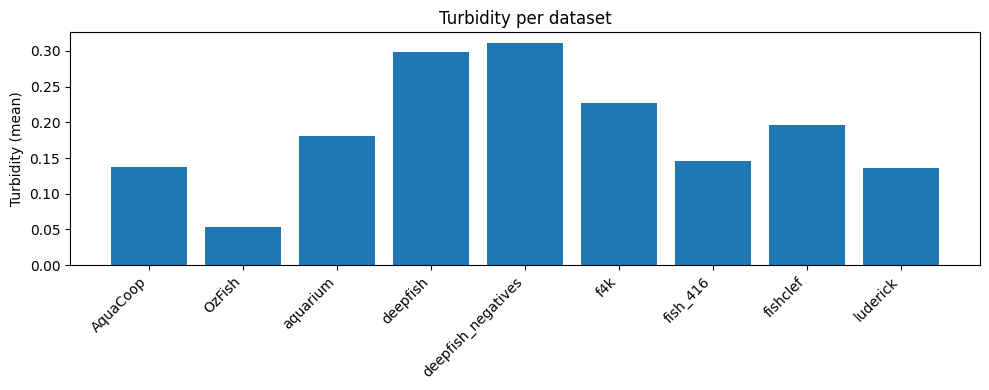

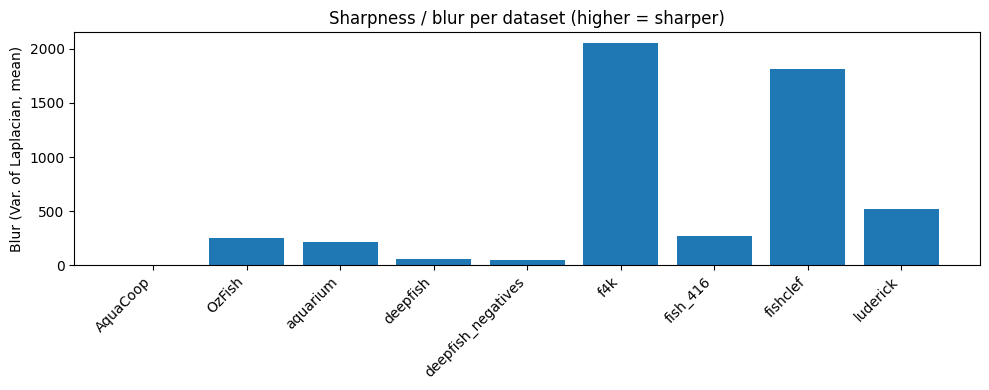

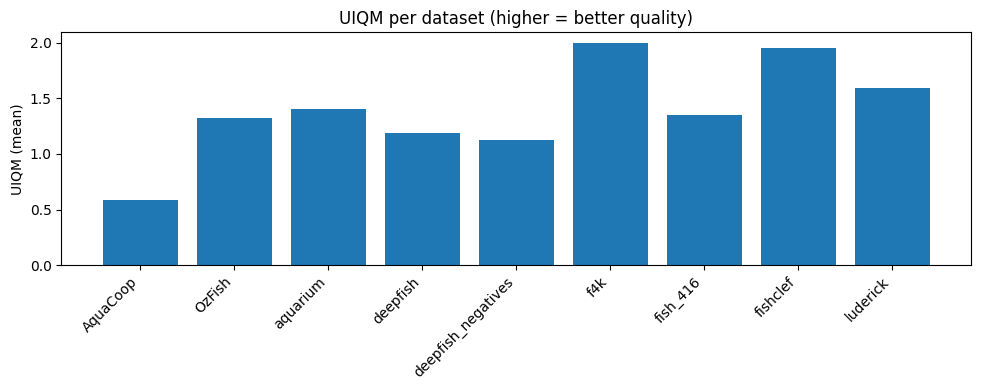

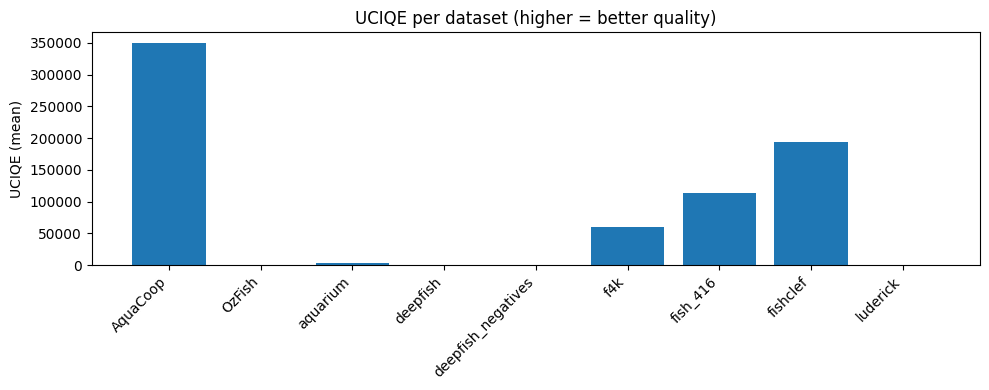

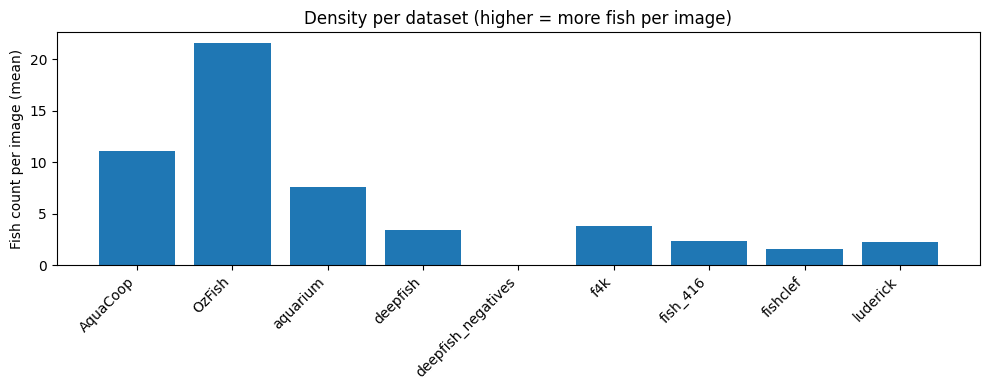

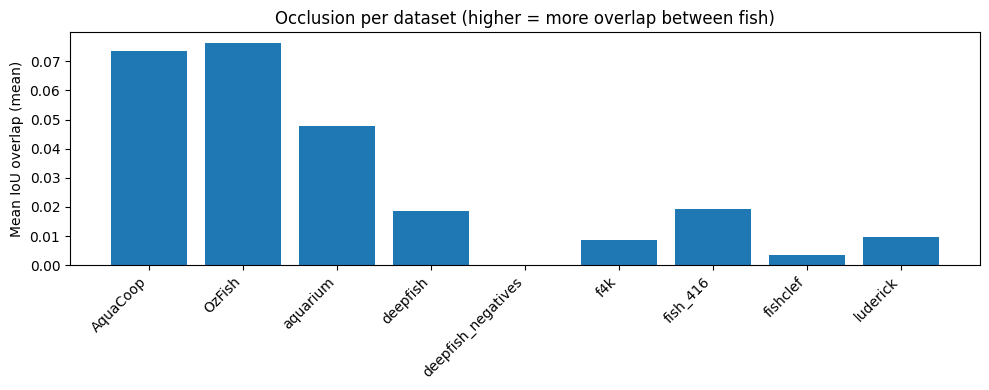

In [8]:
for col in ['turbidity_mean','blur_var_laplacian_mean','uiqm_mean','uciqe_mean','fish_count_mean','mean_iou_overlap_mean']:
    if col in summary.columns:
        summary[col] = pd.to_numeric(summary[col], errors='coerce')

def plot_bar(metric, ylabel, title, sort=False, ascending=False):
    if metric not in summary.columns:
        return
    data = summary[['dataset', metric]].copy()
    data[metric] = pd.to_numeric(data[metric], errors='coerce')
    if sort:
        data = data.sort_values(metric, ascending=ascending)
    labels = data['dataset'].astype(str).tolist()
    heights = data[metric].fillna(0).values
    x = np.arange(len(labels))
    plt.figure(figsize=(10, 4))
    plt.bar(x, heights)
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_bar('turbidity_mean','Turbidity (mean)','Turbidity per dataset', sort=False)
plot_bar('blur_var_laplacian_mean','Blur (Var. of Laplacian, mean)','Sharpness / blur per dataset (higher = sharper)', sort=False)
plot_bar('uiqm_mean','UIQM (mean)','UIQM per dataset (higher = better quality)', sort=False)
plot_bar('uciqe_mean','UCIQE (mean)','UCIQE per dataset (higher = better quality)', sort=False)

if 'fish_count_mean' in summary.columns:
    plot_bar('fish_count_mean','Fish count per image (mean)','Density per dataset (higher = more fish per image)', sort=False)
if 'mean_iou_overlap_mean' in summary.columns:
    plot_bar('mean_iou_overlap_mean','Mean IoU overlap (mean)','Occlusion per dataset (higher = more overlap between fish)', sort=False)

    plt.show()


## 5. Select unseen test domains

Based on the previous tables and plots, select two visually extreme and challenging datasets (in terms of both distortion and density/occlusion) to act as unseen test domains. The remaining datasets will form the training domain pool.


In [ ]:
UNSEEN_DOMAINS = ['AquaCoop', 'OzFish']
TRAIN_DOMAINS = [d for d in summary['dataset'].unique() if d not in UNSEEN_DOMAINS]

print('Unseen test domains:', UNSEEN_DOMAINS)
print('Training domains:', TRAIN_DOMAINS)

## 6. Merge per-image performance with distortions

After training YOLO11m on the training domains and evaluating on the unseen test domains,
export per-image detection metrics (e.g. `per_image_results_case1_test.csv`).  Each row should
contain at least:

- `image_path` (absolute path)
- `dataset`
- `TP`, `FP`, `FN`
- `precision`, `recall`, `f1`

We merge this with `distortions_all_datasets.csv` using the relative image path.

In [ ]:
CSV_PERF_CASE1 = ROOT / 'experiments_crossdomain' / 'per_image_results_case1_test.csv'
CSV_PERF_CASE2 = ROOT / 'experiments_crossdomain' / 'per_image_results_case2_test.csv'

CSV_PERF_CASE1, CSV_PERF_CASE2

In [ ]:
def merge_distortions_and_perf(perf_csv_path: Path):
    perf = pd.read_csv(perf_csv_path)
    perf['path_rel'] = perf['image_path'].str.replace(str(ROOT) + '/', '', regex=False)
    merged = distortions.merge(perf, on='path_rel', how='inner')
    print('Merged rows:', merged.shape[0])
    return merged



## 7. Analyse performance vs. distortions

With the merged tables, we can compute correlations between distortion metrics and performance
(e.g. recall), and visualise how recall changes with increasing turbidity, blur, or decreasing
UIQM/UCIQE.

## 8. Summary

In this notebook we:

- Loaded per-image and per-dataset distortion metrics.
- Compared datasets in terms of turbidity, contrast, blur, colour cast, UIQM and UCIQE.
- Selected visually extreme datasets to act as unseen test domains.
- Prepared code to merge per-image distortion metrics with YOLO performance and analyse how
  performance collapses under different underwater distortions.

This provides the analytical backbone for a controlled cross-domain generalisation experiment
as requested in the thesis feedback.